In [1]:
from matplotlib_inline import backend_inline 
import random
import torch
from d2l import torch as d2l

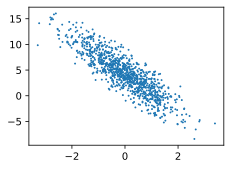

In [16]:
def synthetic_data(w,b,num_examples):  #@save
    #create y=Xw+b+∊
    X=torch.normal(0,1,(num_examples,len(w)))
    y=torch.matmul(X,w)+b #calculate theoretical value
    y+=torch.normal(0,0.1,y.shape)  #collect random error
    return X,y.reshape((-1,1))

true_w=torch.tensor([2,-3.4])
true_b=4.2
features,labels=synthetic_data(true_w,true_b,1000)  

d2l.set_figsize()
d2l.plt.scatter(features[:,1].detach().numpy(),labels.detach().numpy(),1)

In [3]:
def data_iter(batch_size,features,labels):  #@save
    num_examples=len(features)
    indices=list(range(num_examples))
    #randomly read minibatch examples, that is, without specific order
    random.shuffle(indices)  #shuffle the index set
    for i in range(0,num_examples,batch_size):
        batch_indices=torch.tensor(indices[i:min(i+batch_size,num_examples)])
        yield features[batch_indices],labels[batch_indices]  #return a batch of data for each request

In [5]:
batch_size=10
for X,y in data_iter(batch_size,features,labels):
    print(X,'\n',y)
    break

print(f"X shape: {X.shape}, y shape: {y.shape}")

tensor([[ 0.1198,  0.1868],
        [-0.3922,  0.3856],
        [ 0.9450,  1.0234],
        [ 0.2688, -1.1300],
        [ 0.2520,  0.9425],
        [-0.0158,  1.7397],
        [-0.2045,  0.7434],
        [ 1.5480, -1.1435],
        [ 0.2344,  0.8464],
        [-1.1736, -1.1932]]) 
 tensor([[ 3.6928],
        [ 2.1547],
        [ 2.7358],
        [ 8.5585],
        [ 1.3799],
        [-1.8638],
        [ 1.0981],
        [11.1455],
        [ 1.8375],
        [ 5.9218]])
X shape: torch.Size([10, 2]), y shape: torch.Size([10, 1])


In [6]:
w=torch.normal(0,0.01,size=(2,1),requires_grad=True)
b=torch.zeros(1,requires_grad=True)

def linreg(X,w,b):  #@save
    #linear regression model
    return torch.matmul(X,w)+b

def squared_loss(y_est,y):  #@save
    return (y_est-y.reshape(y_est.shape))**2/2

def sgd(params,learning_rate,batch_size):  #@save
    #stochastic gradient descent
    with torch.no_grad():
        for param in params:
            param-=learning_rate*param.grad/batch_size
            param.grad.zero_()

In [23]:
learning_rate=0.01
num_epochs=3
net=linreg
loss=squared_loss

for epoch in range(num_epochs):
    for X,y in data_iter(batch_size,features,labels):
        l=loss(net(X,w,b),y)
        l.sum().backward()
        sgd([w,b],learning_rate,batch_size)
    with torch.no_grad():
        train_loss=loss(net(features,w,b),labels)
        print(f'epoch {epoch+1},loss: {float(train_loss.mean()):f}\n')

print(f'estimated error of w: {true_w-w.reshape(true_w.shape)}')
print(f'estimated error of b: {true_b-b}')

epoch 1,loss: 0.005082

epoch 2,loss: 0.005081

epoch 3,loss: 0.005081

estimated error of w: tensor([-3.3073e-03, -7.3671e-05], grad_fn=<SubBackward0>)
estimated error of b: tensor([-0.0002], grad_fn=<RsubBackward1>)
